Gradient check, worst relative error: 6.45e-09
PASS: backprop is correct
Epoch    0 | train loss 0.7829 | test loss 0.6077
Epoch  500 | train loss 0.0348 | test loss 0.0487
Epoch 1000 | train loss 0.0258 | test loss 0.0510
Epoch 1500 | train loss 0.0217 | test loss 0.0556
Epoch 2000 | train loss 0.0192 | test loss 0.0592
Epoch 2500 | train loss 0.0176 | test loss 0.0642
Epoch 2999 | train loss 0.0163 | test loss 0.0662

Train accuracy: 0.996
Test accuracy:  0.992


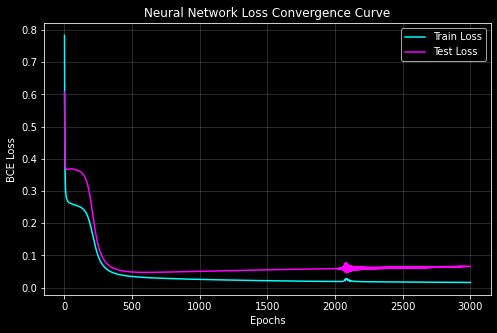


Execution complete.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')   # so titles are readable on a dark notebook
rng = np.random.default_rng(0)

n = 300
t = rng.uniform(0, np.pi, n)
moon1 = np.column_stack([np.cos(t), np.sin(t)])
moon2 = np.column_stack([1 - np.cos(t), 0.5 - np.sin(t)])
X = np.vstack([moon1, moon2]) + rng.normal(0, 0.15, (2 * n, 2))
y = np.concatenate([np.zeros(n), np.ones(n)]).reshape(-1, 1)

idx = rng.permutation(2 * n)
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


def init_params(sizes, seed=1):
    r = np.random.default_rng(seed)
    Ws = [r.normal(0, 1, (sizes[i], sizes[i + 1])) * np.sqrt(1 / sizes[i])
          for i in range(len(sizes) - 1)]
    bs = [np.zeros((1, sizes[i + 1])) for i in range(len(sizes) - 1)]
    return Ws, bs

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def forward(X, Ws, bs):
    A = X
    cache = [A]                        
    L = len(Ws)
    for l in range(L):
        Z = A @ Ws[l] + bs[l]
        A = sigmoid(Z) if l == L - 1 else np.tanh(Z)
        cache.append(A)
    return A, cache


def bce_loss(a, y):
    eps = 1e-12
    a = np.clip(a, eps, 1 - eps)
    return -np.mean(y * np.log(a) + (1 - y) * np.log(1 - a))


def backward(y, Ws, cache):
    m = y.shape[0]
    L = len(Ws)
    dWs = [None] * L
    dbs = [None] * L
    dZ = (cache[-1] - y) / m
    for l in range(L - 1, -1, -1):
        dWs[l] = cache[l].T @ dZ
        dbs[l] = np.sum(dZ, axis=0, keepdims=True)
        if l > 0:
            dA = dZ @ Ws[l].T
            dZ = dA * (1 - cache[l] ** 2)
    return dWs, dbs


def gradient_check(Xs, ys, sizes, h=1e-5):
    Ws, bs = init_params(sizes, seed=5)
    a, cache = forward(Xs, Ws, bs)
    dWs, dbs = backward(ys, Ws, cache)
    worst = 0.0
    for params, grads in [(Ws, dWs), (bs, dbs)]:
        for P, G in zip(params, grads):
            for ix in np.ndindex(P.shape):
                old = P[ix]
                P[ix] = old + h
                lp = bce_loss(forward(Xs, Ws, bs)[0], ys)
                P[ix] = old - h
                lm = bce_loss(forward(Xs, Ws, bs)[0], ys)
                P[ix] = old
                num = (lp - lm) / (2 * h)
                rel = abs(num - G[ix]) / max(1e-12, abs(num) + abs(G[ix]))
                worst = max(worst, rel)
    return worst

err = gradient_check(X_train[:10], y_train[:10], [2, 4, 3, 1])
print(f"Gradient check, worst relative error: {err:.2e}")
print("PASS: backprop is correct" if err < 1e-6 else "FAIL: there is a bug")


sizes = [2, 16, 8, 1]
Ws, bs = init_params(sizes)
lr, epochs = 0.5, 3000
train_losses, test_losses = [], []

for epoch in range(epochs):
    a, cache = forward(X_train, Ws, bs)
    dWs, dbs = backward(y_train, Ws, cache)
    for l in range(len(Ws)):
        Ws[l] -= lr * dWs[l]
        bs[l] -= lr * dbs[l]

    train_losses.append(bce_loss(a, y_train))
    test_losses.append(bce_loss(forward(X_test, Ws, bs)[0], y_test))
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:4d} | train loss {train_losses[-1]:.4f} | test loss {test_losses[-1]:.4f}")


def accuracy(X, y):
    pred = (forward(X, Ws, bs)[0] > 0.5).astype(float)
    return np.mean(pred == y)

print(f"\nTrain accuracy: {accuracy(X_train, y_train):.3f}")
print(f"Test accuracy:  {accuracy(X_test, y_test):.3f}")

# Plotting the loss convergence curve securely
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='cyan')
plt.plot(test_losses, label='Test Loss', color='magenta')
plt.title("Neural Network Loss Convergence Curve")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()
print("\nExecution complete.")